In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
#from pytorch_ranger import Ranger
from sklearn.model_selection import KFold
import torchvision.models as models

In [2]:
!unzip GatheredData.zip

Archive:  GatheredData.zip
   creating: GatheredData/
   creating: GatheredData/Fall/
  inflating: GatheredData/Fall/Areeb_back_1.csv  
  inflating: GatheredData/Fall/Areeb_back_2.csv  
  inflating: GatheredData/Fall/Areeb_back_3.csv  
  inflating: GatheredData/Fall/Areeb_back_4.csv  
  inflating: GatheredData/Fall/Areeb_back_5.csv  
  inflating: GatheredData/Fall/Areeb_front_1.csv  
  inflating: GatheredData/Fall/Areeb_front_2.csv  
  inflating: GatheredData/Fall/Areeb_front_3.csv  
  inflating: GatheredData/Fall/Areeb_front_4.csv  
  inflating: GatheredData/Fall/Areeb_front_5.csv  
  inflating: GatheredData/Fall/Areeb_front_6.csv  
  inflating: GatheredData/Fall/Areeb_front_7.csv  
  inflating: GatheredData/Fall/Areeb_side_1.csv  
  inflating: GatheredData/Fall/Areeb_side_2.csv  
  inflating: GatheredData/Fall/Areeb_side_3.csv  
  inflating: GatheredData/Fall/Areeb_side_4.csv  
  inflating: GatheredData/Fall/Areeb_side_5.csv  
  inflating: GatheredData/Fall/Raffay_back_1.csv  
  infl

# Functions for modifying data

In [3]:
#function for making the number of frames equal to a certain number by filling zeroes given the df of a single file

def fillframes(frame_num, file_id, df):
    max_frame = df['frame'].max()
    cont_list = set(range(max_frame+1))
    missing_frames = sorted(list(cont_list - set(df['frame'])))

    for i in missing_frames:
        if i == 0:
            newdf = pd.DataFrame([{'frame':0, 'DetObj#':0, 'x':0, 'y':0, 'z':0, 'v':0, 'source_file_id':file_id}])
            df = pd.concat([newdf, df], ignore_index=True).reset_index(drop=True)
        else:
            index_tochange = df[df['frame'] == i-1].index[-1]
            newdf = pd.DataFrame([{'frame':i, 'DetObj#':0, 'x':0, 'y':0, 'z':0, 'v':0, 'source_file_id':file_id}])
            df = pd.concat([df.iloc[:index_tochange+1], newdf, df.iloc[index_tochange+1:]]).reset_index(drop=True)

    if max_frame != frame_num:
        index_tochange = df.index[-1]
        for i in range(max_frame+1, frame_num+1):
            newdf = pd.DataFrame([{'frame':i, 'DetObj#':0, 'x':0, 'y':0, 'z':0, 'v':0, 'source_file_id':file_id}])
            df = pd.concat([df.iloc[:index_tochange+1], newdf, df.iloc[index_tochange+1:]]).reset_index(drop=True)
            index_tochange += 1


    return df

In [4]:
#function for making the number of points equal to a certain number in all frames of a file
def fillpoints(maxpoints, file_id, df):

    for i in range(df['frame'].max()+1): #looping through frames
        df_thisframe = df[df['frame']==i]
        if df_thisframe['DetObj#'].max() < maxpoints:
            thisframe_maxpoints = df_thisframe['DetObj#'].max()
            index_tochange = df_thisframe.index[-1]

            newdf = pd.DataFrame(np.zeros((maxpoints - thisframe_maxpoints, 4)), columns=['x', 'y', 'z', 'v'])
            newdf['frame'] = i
            newdf['DetObj#'] = range(thisframe_maxpoints+1, maxpoints+1)
            newdf['source_file_id'] = file_id

            df = pd.concat([df.iloc[:index_tochange+1], newdf, df.iloc[index_tochange+1:]]).reset_index(drop=True)

    return df

# Loading and modifying data

In [5]:
fall_newfiles = glob.glob('GatheredData/Fall/*.csv')
not_newfiles = glob.glob('GatheredData/Not/*.csv')
fall_newdf = pd.DataFrame()
not_newdf = pd.DataFrame()

In [6]:
#Making the Dataframe for the fall files

countFile = 0

for file in fall_newfiles:

    temp_df = pd.read_csv(file)
    temp_df['source_file_id'] = countFile
    countFile += 1

    fall_newdf = pd.concat([fall_newdf, temp_df], ignore_index=True)

In [7]:
#Making the Dataframe for the not files

for file in not_newfiles:

    temp_df = pd.read_csv(file)
    temp_df['source_file_id'] = countFile
    countFile += 1

    not_newdf = pd.concat([not_newdf, temp_df], ignore_index=True)

In [8]:
#Making a Dataframe that contains both, fall and not files
combined_newdf = pd.concat([fall_newdf, not_newdf], ignore_index=True)
combined_newdf.fillna(0, inplace=True)
combined_newdf

,frame,DetObj#,x,y,z,v,snr,noise,source_file_id
0,0,0,-0.110403,0.027237,-0.013134,0.000000,358,420,0
1,0,1,-0.432412,1.683034,-0.443311,0.000000,161,574,0
2,0,2,-0.506014,2.016707,-0.284555,0.000000,158,643,0
3,0,3,1.324835,2.396472,-0.221756,0.000000,117,556,0
4,0,4,0.634817,0.547496,0.259677,0.019900,263,391,0
...,...,...,...,...,...,...,...,...,...
22691,23,1,-0.898980,0.492950,0.039272,0.000000,274,374,101
22692,23,2,-0.867981,1.134568,0.150573,0.000000,193,504,101
22693,23,3,-0.633272,1.793303,0.117463,0.000000,130,688,101
22694,23,4,1.682820,2.395586,-0.151056,0.000000,164,615,101


In [9]:
#Adding frames to files to make them all equal
max_frames = combined_newdf.groupby('source_file_id').agg({'frame':'max'})['frame'].max()
modded_newdf = pd.DataFrame()
for i in range(combined_newdf['source_file_id'].max()+1): #looping through all files
    temp_df = fillframes(max_frames, i, combined_newdf[combined_newdf['source_file_id']==i])
    modded_newdf = pd.concat([modded_newdf, temp_df], ignore_index=True)
    if (i%10==0): print('File No. ' +str(i)+ ' done!')
modded_newdf.fillna(0, inplace=True)
modded_newdf

File No. 0 done!
File No. 10 done!
File No. 20 done!
File No. 30 done!
File No. 40 done!
File No. 50 done!
File No. 60 done!
File No. 70 done!
File No. 80 done!
File No. 90 done!
File No. 100 done!


,frame,DetObj#,x,y,z,v,snr,noise,source_file_id
0,0,0,-0.110403,0.027237,-0.013134,0.000000,358.0,420.0,0
1,0,1,-0.432412,1.683034,-0.443311,0.000000,161.0,574.0,0
2,0,2,-0.506014,2.016707,-0.284555,0.000000,158.0,643.0,0
3,0,3,1.324835,2.396472,-0.221756,0.000000,117.0,556.0,0
4,0,4,0.634817,0.547496,0.259677,0.019900,263.0,391.0,0
...,...,...,...,...,...,...,...,...,...
22783,23,2,-0.867981,1.134568,0.150573,0.000000,193.0,504.0,101
22784,23,3,-0.633272,1.793303,0.117463,0.000000,130.0,688.0,101
22785,23,4,1.682820,2.395586,-0.151056,0.000000,164.0,615.0,101
22786,23,5,-1.016778,0.636266,-0.076820,-0.060451,179.0,390.0,101


In [10]:
#checking if all files have same number of frames
modded_newdf = modded_newdf.sort_values(by=['source_file_id', 'frame', 'DetObj#']).reset_index(drop=True)
modded_newdf.groupby('source_file_id').agg({'frame':'max'}).values.min()

np.int64(24)

In [11]:
#Adding points to files to make them all equal
max_detobj = modded_newdf.groupby(['source_file_id','frame']).agg({'DetObj#':'max'}).values.max()
equal_newdf = pd.DataFrame()
for i in range(modded_newdf['source_file_id'].max()+1): #Looping through all files
    temp_df = fillpoints(max_detobj, i, modded_newdf[modded_newdf['source_file_id']==i])
    equal_newdf = pd.concat([equal_newdf, temp_df], ignore_index=True)
    if (i%10) == 0: print('File No. ' + str(i) + ' is done!')
equal_newdf.fillna(0, inplace=True)
equal_newdf

File No. 0 is done!
File No. 10 is done!
File No. 20 is done!
File No. 30 is done!
File No. 40 is done!
File No. 50 is done!
File No. 60 is done!
File No. 70 is done!
File No. 80 is done!
File No. 90 is done!
File No. 100 is done!


,frame,DetObj#,x,y,z,v,snr,noise,source_file_id
0,0,0,-0.110403,0.027237,-0.013134,0.0000,358.0,420.0,0
1,0,1,-0.432412,1.683034,-0.443311,0.0000,161.0,574.0,0
2,0,2,-0.506014,2.016707,-0.284555,0.0000,158.0,643.0,0
3,0,3,1.324835,2.396472,-0.221756,0.0000,117.0,556.0,0
4,0,4,0.634817,0.547496,0.259677,0.0199,263.0,391.0,0
...,...,...,...,...,...,...,...,...,...
56095,0,17,0.000000,0.000000,0.000000,0.0000,0.0,0.0,101
56096,0,18,0.000000,0.000000,0.000000,0.0000,0.0,0.0,101
56097,0,19,0.000000,0.000000,0.000000,0.0000,0.0,0.0,101
56098,0,20,0.000000,0.000000,0.000000,0.0000,0.0,0.0,101


In [12]:
#checking if all frames of all files haves same number of points
equal_newdf = equal_newdf.sort_values(by=['source_file_id', 'frame', 'DetObj#']).reset_index(drop=True)
equal_newdf.groupby(['source_file_id','frame']).agg({'DetObj#':'max'}).values.min()
max_detobj = modded_newdf.groupby(['source_file_id','frame']).agg({'DetObj#':'max'}).values.max()
print(max_detobj)

21


In [13]:
equal_newdf

,frame,DetObj#,x,y,z,v,snr,noise,source_file_id
0,0,0,-0.110403,0.027237,-0.013134,0.0000,358.0,420.0,0
1,0,1,-0.432412,1.683034,-0.443311,0.0000,161.0,574.0,0
2,0,2,-0.506014,2.016707,-0.284555,0.0000,158.0,643.0,0
3,0,3,1.324835,2.396472,-0.221756,0.0000,117.0,556.0,0
4,0,4,0.634817,0.547496,0.259677,0.0199,263.0,391.0,0
...,...,...,...,...,...,...,...,...,...
56095,24,17,0.000000,0.000000,0.000000,0.0000,0.0,0.0,101
56096,24,18,0.000000,0.000000,0.000000,0.0000,0.0,0.0,101
56097,24,19,0.000000,0.000000,0.000000,0.0000,0.0,0.0,101
56098,24,20,0.000000,0.000000,0.000000,0.0000,0.0,0.0,101


In [14]:
#reshaping the matrix containing features
feats_new = equal_newdf[['x','y','z','v']].values
# Use -1 to automatically infer the batch size instead of hardcoding 102
feat_newmatrix = feats_new.reshape(-1, 25, 22, 4)

feat_newmatrix.shape

(102, 25, 22, 4)

In [15]:
#Making array for labels
labels_newarr = np.concatenate((np.ones(102 // 2), np.zeros(102 // 2)))

torch.tensor(labels_newarr).shape

torch.Size([102])

# CNN Model Architecture

In [16]:
import torch.nn.functional as F

# Define the CNN model
class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        self.conv1 = nn.Conv2d(25, 16, kernel_size=5, stride=2, padding=2, dtype=torch.float32)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1, dtype=torch.float32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 5 * 1, 64, dtype=torch.float32)
        self.fc2 = nn.Linear(64, 32, dtype=torch.float32)
        self.fc3 = nn.Linear(32, 1, dtype=torch.float32)


    def forward(self, x):
        x = self.conv1(x)
        x = F.leaky_relu(x, negative_slope=0.01)
        x = self.pool(x)
        x = self.conv2(x)
        x = F.leaky_relu(x, negative_slope=0.01)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = F.leaky_relu(x, negative_slope=0.01)
        x = self.fc2(x)
        x = F.leaky_relu(x, negative_slope=0.01)
        x = self.fc3(x)
        return x

# Training and Testing the model

In [17]:
#splitting data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(torch.tensor(feat_newmatrix), torch.tensor(labels_newarr, dtype=torch.long), test_size=0.3, random_state=30)

#Creating a Training DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)

#Creating a Testing DataLoader
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=False)

In [18]:
#Instantiateing the model, loss function, and optimizer
model = MyCNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [19]:
num_epochs = 10
trainloss_list = []
testloss_list = []
trainaccuracy_list = []
testaccuracy_list = []

for epoch in range(num_epochs):

    #Training loop
    model.train()
    correct = 0
    total = 0
    for matrices, label in train_loader:
        optimizer.zero_grad() #variables reset
        outputs = model(matrices.float()) #obtaining predictions
        label = label.view(-1, 1)
        # FIX: Changed 'output' to 'outputs' below
        trainloss = criterion(outputs, label.float())
        trainloss.backward() #backpropagation
        optimizer.step() #optimizing parameter
        total += label.size(0)
        # FIX: Changed 'output' to 'outputs' below
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predicted == label).sum().item()
    trainloss_list.append(trainloss.item())
    trainaccuracy_list.append(correct/total)

    #Testing loop
    model.eval()
    acctestloss = 0.0
    correct = 0
    total = 0

    #Disable gradient computation
    with torch.no_grad():
        for matrices, labels in test_loader:
            outputs = model(matrices.float())  # Forward pass
            labels = labels.view(-1, 1)
            testloss = criterion(outputs, labels.float())
            acctestloss += testloss.item()  # Accumulate the loss

            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total += labels.size(0)  # Increment the total count of samples
            correct += (predicted == labels).sum().item()  # Increment the correct count
    testloss_list.append(testloss.item())
    testaccuracy_list.append(correct/total)

    #Calculating the average test loss
    avg_test_loss = acctestloss / len(test_loader)

    #Calculating the accuracy
    accuracy = correct / total





    print(f'Epoch {epoch + 1}/{num_epochs}, Training Loss: {trainloss.item()}, Testing Loss: {testloss.item()}')

accuracy

Epoch 1/10, Training Loss: 0.705868661403656, Testing Loss: 0.6883397102355957
Epoch 2/10, Training Loss: 0.5543474555015564, Testing Loss: 0.855587899684906
Epoch 3/10, Training Loss: 0.6818147897720337, Testing Loss: 0.7956621646881104
Epoch 4/10, Training Loss: 0.144659161567688, Testing Loss: 1.2299292087554932
Epoch 5/10, Training Loss: 0.20718634128570557, Testing Loss: 0.5930221676826477
Epoch 6/10, Training Loss: 0.0005078315734863281, Testing Loss: 0.010259628295898438
Epoch 7/10, Training Loss: 0.0031366348266601562, Testing Loss: 1.7521655559539795
Epoch 8/10, Training Loss: 0.0022668838500976562, Testing Loss: 0.011640548706054688
Epoch 9/10, Training Loss: 0.009882637299597263, Testing Loss: 0.0415651798248291
Epoch 10/10, Training Loss: 6.615449819946662e-05, Testing Loss: 0.10425686836242676


0.7096774193548387

In [20]:
#Testing the model
model.eval()
test_loss = 0.0
correct = 0
total = 0
loss_list = []
pred_list = []
true_list = []

# Disable gradient computation
with torch.no_grad():
    for matrices, labels in test_loader:
        outputs = model(matrices.float())  #Forward pass
        labels = labels.view(-1, 1)
        loss = criterion(outputs, labels.float())
        loss_list.append(loss)
        test_loss += loss.item()  #Accumulate the loss

        predicted = (torch.sigmoid(outputs) > 0.5).float()
        pred_list.append(predicted)
        true_list.append(labels)
        total += labels.size(0)  #Increment the total count of samples
        correct += (predicted == labels).sum().item()  #Increment the correct count

#Calculating the average test loss
avg_test_loss = test_loss / len(test_loader)

#Calculating the accuracy
accuracy = correct / total

#Calculating F1 score

true_list = [item for sublist in true_list for item in sublist.numpy()]
pred_list = [item for sublist in pred_list for item in sublist.numpy()]


f1 = f1_score(true_list, pred_list)
print(f'F1 Score: {f1}')

print(correct)
print(total)
print(f'Average Test Loss: {avg_test_loss:.4f}, Accuracy: {accuracy:.4f}')

F1 Score: 0.6666666666666666
22
31
Average Test Loss: 0.6811, Accuracy: 0.7097


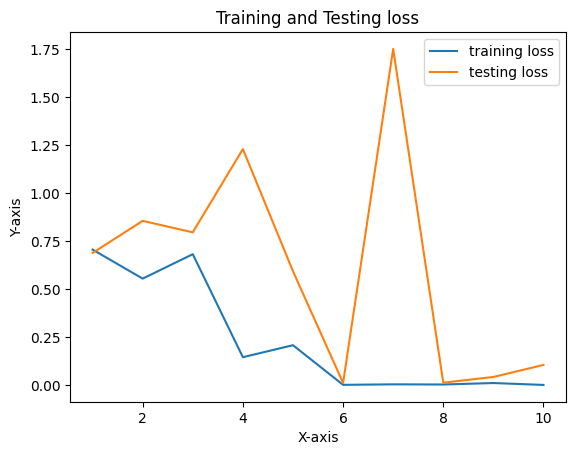

In [21]:
x_values = range(1, len(trainloss_list) + 1)
#Plotting the first line
plt.plot(x_values, trainloss_list, label='training loss')

#Plotting the second line
plt.plot(x_values, testloss_list, label='testing loss')

#Adding labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Training and Testing loss')

#Adding legend
plt.legend()

#Displaying the plot
plt.show()

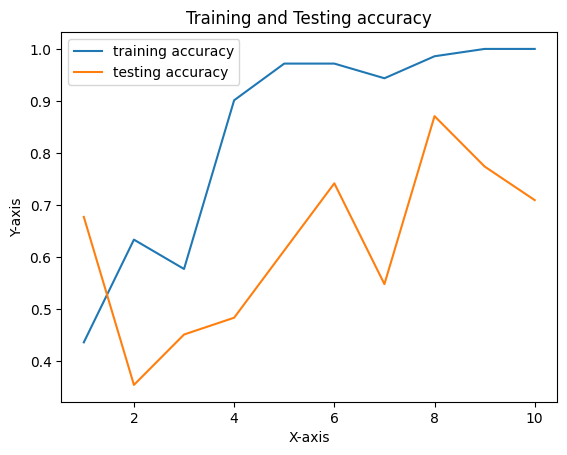

In [22]:
x_values = range(1, len(trainaccuracy_list) + 1)
#Plotting the first line
plt.plot(x_values, trainaccuracy_list, label='training accuracy')

#Plotting the second line
plt.plot(x_values, testaccuracy_list, label='testing accuracy')

#Adding labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Training and Testing accuracy')

#Adding legend
plt.legend()

#Displaying the plot
plt.show()

# Cross Validation

In [23]:
#Defining the number of folds
num_folds = 5
kf = KFold(n_splits=num_folds)
num_epochs = 10

train_loss_fold = []
test_loss_fold = []
train_accuracy_fold = []
test_accuracy_fold = []

for fold, (train_indices, test_indices) in enumerate(kf.split(feat_newmatrix)):
    print(f'Fold {fold + 1}/{num_folds}')

    #Instantiating the model for this fold
    model = MyCNN()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    #Instantiating the model for this fold
    model = MyCNN()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    #Splitting data into train and test sets for this fold
    X_train_fold, X_test_fold = feat_newmatrix[train_indices], feat_newmatrix[test_indices]
    y_train_fold, y_test_fold = labels_newarr[train_indices], labels_newarr[test_indices]

    #Creating DataLoader for training
    train_dataset_fold = TensorDataset(torch.tensor(X_train_fold), torch.tensor(y_train_fold, dtype=torch.long))
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=5, shuffle=True)

    #Creating DataLoader for testing
    test_dataset_fold = TensorDataset(torch.tensor(X_test_fold), torch.tensor(y_test_fold, dtype=torch.long))
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=5, shuffle=False)


    train_loss_list = []
    test_loss_list = []
    train_accuracy_list = []
    test_accuracy_list = []

    for epoch in range(num_epochs):

        #Training loop
        model.train()
        correct_train = 0
        total_train = 0
        for matrices, label in train_loader_fold:
            optimizer.zero_grad()
            outputs = model(matrices.float())
            label = label.view(-1, 1)
            # FIX: Changed 'output' to 'outputs' below
            train_loss = criterion(outputs, label.float())
            train_loss.backward()
            optimizer.step()
            total_train += label.size(0)
            # FIX: Changed 'output' to 'outputs' below
            predicted_train = (torch.sigmoid(outputs) > 0.5).float()
            correct_train += (predicted_train == label).sum().item()
        train_loss_list.append(train_loss.item())
        train_accuracy_list.append(correct_train / total_train)

        #Testing loop
        model.eval()
        acc_test_loss = 0.0
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for matrices, labels in test_loader_fold:
                outputs = model(matrices.float())
                labels = labels.view(-1, 1)
                test_loss = criterion(outputs, labels.float())
                acc_test_loss += test_loss.item()

                predicted_test = (torch.sigmoid(outputs) > 0.5).float()
                total_test += labels.size(0)
                correct_test += (predicted_test == labels).sum().item()
        test_loss_list.append(test_loss.item())
        test_accuracy_list.append(correct_test / total_test)

        print(f'Epoch {epoch + 1}/{num_epochs}, Training Loss: {train_loss.item()}, Testing Loss: {test_loss.item()}')

    #Storing results for this fold
    train_loss_fold.append(train_loss_list)
    test_loss_fold.append(test_loss_list)
    train_accuracy_fold.append(train_accuracy_list)
    test_accuracy_fold.append(test_accuracy_list)


Fold 1/5
Epoch 1/10, Training Loss: 0.3831014037132263, Testing Loss: 1.016058087348938
Epoch 2/10, Training Loss: 0.8802322149276733, Testing Loss: 0.9691537022590637
Epoch 3/10, Training Loss: 0.9037243723869324, Testing Loss: 1.0989158153533936
Epoch 4/10, Training Loss: 0.10577988624572754, Testing Loss: 1.1191502809524536
Epoch 5/10, Training Loss: 0.14850270748138428, Testing Loss: 0.49238482117652893
Epoch 6/10, Training Loss: 0.011998500674962997, Testing Loss: 0.08920707553625107
Epoch 7/10, Training Loss: 0.0023531296756118536, Testing Loss: 0.1903659999370575
Epoch 8/10, Training Loss: 0.00041866302490234375, Testing Loss: 0.19083085656166077
Epoch 9/10, Training Loss: 0.00013828277587890625, Testing Loss: 0.14966586232185364
Epoch 10/10, Training Loss: 0.00017370142450090498, Testing Loss: 0.15725503861904144
Fold 2/5
Epoch 1/10, Training Loss: 0.5684002041816711, Testing Loss: 0.8378719687461853
Epoch 2/10, Training Loss: 0.45385390520095825, Testing Loss: 1.02444791793823

In [24]:
for i in range(len(train_loss_fold)):
    print(f'FOR FOLD {i}:')
    print(f'train loss = {train_loss_fold[i][num_epochs-1]}')
    print(f'test loss = {test_loss_fold[i][num_epochs-1]}')
    print(f'train accuracy = {train_accuracy_fold[i][num_epochs-1]}')
    print(f'test accuracy = {test_accuracy_fold[i][num_epochs-1]}')

FOR FOLD 0:
train loss = 0.00017370142450090498
test loss = 0.15725503861904144
train accuracy = 1.0
test accuracy = 0.7619047619047619
FOR FOLD 1:
train loss = 8.7738037109375e-05
test loss = 0.016728296875953674
train accuracy = 0.9876543209876543
test accuracy = 1.0
FOR FOLD 2:
train loss = 0.0001622493437025696
test loss = 0.8322596549987793
train accuracy = 1.0
test accuracy = 0.85
FOR FOLD 3:
train loss = 0.00015183296636678278
test loss = 1.77288019657135
train accuracy = 1.0
test accuracy = 0.65
FOR FOLD 4:
train loss = 2.978537122544367e-05
test loss = 0.5536396503448486
train accuracy = 1.0
test accuracy = 0.75


In [25]:
#Creating a Testing DataLoader
test_dataset = TensorDataset(torch.tensor(feat_newmatrix), torch.tensor(labels_newarr, dtype=torch.long))
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=False)

#Testing the model
model.eval()
test_loss = 0.0
correct = 0
total = 0
loss_list = []
pred_list = []
true_list = []

# Disable gradient computation
with torch.no_grad():
    for matrices, labels in test_loader:
        # FIX: Changed 'output' to 'outputs' below
        outputs = model(matrices.float())  #Forward pass
        labels = labels.view(-1, 1)
        loss = criterion(outputs, labels.float())  #Calculate the loss
        loss_list.append(loss)
        test_loss += loss.item()  #Accumulate the loss

        predicted = (torch.sigmoid(outputs) > 0.5).float()
        pred_list.append(predicted)
        true_list.append(labels)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

#Calculating the average test loss
avg_test_loss = test_loss / len(test_loader)

#Calculating the accuracy
accuracy = correct / total

#Calculating F1 score

true_list = [item for sublist in true_list for item in sublist.numpy()]
pred_list = [item for sublist in pred_list for item in sublist.numpy()]


f1 = f1_score(true_list, pred_list)
print(f'F1 Score: {f1}')

print(correct)
print(total)
print(f'Average Test Loss: {avg_test_loss:.4f}, Accuracy: {accuracy:.4f}')

F1 Score: 0.9532710280373832
97
102
Average Test Loss: 0.1844, Accuracy: 0.9510


# Testing on new file

In [26]:
newfile = pd.read_csv('GatheredData/Fall/Areeb_back_2.csv')  # replace the string with the path to the file
newfile['source_file_id'] = 0

In [27]:
newfile = fillframes(modded_newdf.groupby('source_file_id').agg({'frame':'max'}).values.min(), 0, newfile)
newfile = fillpoints(equal_newdf.groupby(['source_file_id','frame']).agg({'DetObj#':'max'}).values.min(), 0, newfile)
newfile = newfile.sort_values(by=['frame', 'DetObj#']).reset_index(drop=True)
newfile

,frame,DetObj#,x,y,z,v,snr,noise,source_file_id
0,0,0,-0.106953,0.039876,-0.008615,0.0,305.0,473.0,0
1,0,1,0.455412,0.703981,-0.040876,0.0,278.0,446.0,0
2,0,2,-0.432412,1.729265,-0.196896,0.0,184.0,544.0,0
3,0,3,-0.115003,1.876584,-0.324012,0.0,122.0,605.0,0
4,0,4,-0.569265,2.016376,-0.119555,0.0,128.0,670.0,0
...,...,...,...,...,...,...,...,...,...
545,24,17,0.000000,0.000000,0.000000,0.0,NaN,NaN,0
546,24,18,0.000000,0.000000,0.000000,0.0,NaN,NaN,0
547,24,19,0.000000,0.000000,0.000000,0.0,NaN,NaN,0
548,24,20,0.000000,0.000000,0.000000,0.0,NaN,NaN,0


In [28]:
featsarr_new = newfile[['x','y','z','v']].values
new = featsarr_new.reshape(1, modded_newdf.groupby('source_file_id').agg({'frame':'max'}).values.min()+1,
                           equal_newdf.groupby(['source_file_id','frame']).agg({'DetObj#':'max'}).values.min()+1, 4)
new.shape

(1, 25, 22, 4)

In [29]:
pred_data = TensorDataset(torch.tensor(new))
pred_loader = DataLoader(pred_data, batch_size=1, shuffle=False)

In [30]:
model.eval()
pred_value = model(torch.tensor(new, dtype=torch.float32))
if int((torch.sigmoid(pred_value) > 0.5).float()[0][0]) == 1:
    print('FALL!')
else:
    print('NOT FALL!')

FALL!


In [31]:
# Save the model state dictionary for edge deployment
torch.save(model.state_dict(), 'fall_model.pth')
print("Successfully exported fall_model.pth!")

Successfully exported fall_model.pth!
